In [ ]:
from datascience import *
%matplotlib inline
path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

# Simulations

## Simulating the roll of a die

In [ ]:
die_faces = np.arange(1, 7)

In [ ]:
np.random.choice(die_faces)

## Playing the Dice Game

**What are the rules of this game based on the code?**

In [ ]:
def one_round(my_roll, your_roll):
    if my_roll > your_roll:
        return 1
    elif your_roll > my_roll:
        return -1
    elif your_roll == my_roll:
        return 0

def simulate_one_round():
    my_roll = np.random.choice(die_faces)
    your_roll = np.random.choice(die_faces)
    return one_round(my_roll, your_roll)

In [ ]:
simulate_one_round()

## Simulating heads in 100 coin tosses

In [ ]:
coin = make_array('heads', 'tails')

In [ ]:
coin_choices = np.random.choice(coin, 1000)
coin_heads = sum(coin_choices == 'heads')
coin_tails = sum(coin_choices == 'tails')

print(f"Heads: {coin_heads}")
print(f"Tails: {coin_tails}")
print(coin_choices)

In [ ]:
#Simulate one outcome

def num_heads(n):
    return sum(np.random.choice(coin, n) == 'heads')

In [ ]:
# Decide how many times you want to repeat the experiment

repetitions = 10000

In [ ]:
# Simulate that many outcomes

outcomes = make_array()

for i in np.arange(repetitions):
    outcomes = np.append(outcomes, num_heads(100))

In [ ]:
heads = Table().with_column('Heads', outcomes)
heads.hist(bins = np.arange(29.5, 70.6))

# Lecture 14: Probability
## Notation and Basics

* Theoretical Probability:
* Empirical Probability:

Event: 

Probability of an Event: 

Important! Notation: 

## Types of Events in Probability

Lowest possible value for probability:
   * What type of event is that?

Highest possibly value for proability:
   * What type of event is that?

Not Event:

AND Event:

OR Event: 







### Applying Probability as Chance

First we create a box that contains three cards labeled R, B, and G. 

In [ ]:
#Create an array that contains the given cards
items = make_array('R', 'B', 'G')
items

### Chance of event occuring

If I draw one card at random, what is the chance that I get an R?

In [ ]:
# How would you calculate this value?

prob_R =  np.count_nonzero(items == 'R') / len(items)
prob_R

### Chance of two events both occurring ###
If I **draw two cards at random without replacement**, What is the chance that I get G followed by B?

(both "get G first" and "get B second")

In [ ]:
# The first probability is similar to the previous problem.
prob_G =  np.count_nonzero(items == 'G') / len(items)

# w
items2 = make_array('R', 'B')
prob_B =  np.count_nonzero(items == 'B') / len(items2)
prob_G_AND_B = prob_G * prob_B
prob_G_AND_B

In [ ]:
#Define a function that will calculate an AND probability
def probability_of_selection(arr_1, item_1, item_2):
     # Validate not an impossible event
    if item_1 not in arr_1 or item_2 not in arr_1 or item_1 == item_2:
        return 0
    
    # Compute Probability 1
    prob_1 =  np.count_nonzero(arr_1 == item_1) / len(arr_1)
    
    # Compute Probability 2
    arr_2 = make_array()
    for item in arr_1:
        if item != item_1:
            arr_2 = np.append(arr_2, item)
    prob_2 = np.count_nonzero(arr_2 == item_2) / len(arr_2)
    
    #Compute Total Probability
    return prob_1 * prob_2
    

In [ ]:
#Use your function to answer the question
result = probability_of_selection(items, 'G', 'B')
result

In [ ]:
#Probabilities are often stated as fractions. Limiting the denominator helps with fraction display.
from fractions import Fraction
f = Fraction(*result.as_integer_ratio())
f = f.limit_denominator(100)
print (f)

What is the chance that I get R followed by G?

(both "get R first" and "get G second")

In [ ]:
result_rg = probability_of_selection(items, 'R', 'G')
result_rg

### Chance of an event that can happen in multiple ways ###
What is the chance that one of the cards is G and the other is B? Meaning, the order does not matter. 

In [ ]:
g_or_b = probability_of_selection(items, 'B', 'G') + probability_of_selection(items, 'G', 'B')
g_or_b

In [ ]:
f = Fraction(*g_or_b.as_integer_ratio())
f = f.limit_denominator(100)
print (f)

### Challenge Question 1 ###

**Without calculation:** What is the chance that the second card drawn is B?

### Challenge Question 2 ###

I have a deck of 52 cards. It contains four aces, one of which is the ace of hearts.

I shuffle the deck and deal 13 cards. 

**Without calculation:** What is the chance that the 12th card is the ace of hearts?

### Chance of At Least One Success in Independently Repeated Success/Failure Trials ###

In [ ]:
# Chance of no sixes in 4 rolls of a die

prob_no_sixes_in_four_rolls = (5/6) ** 4
prob_no_sixes_in_four_rolls

In [ ]:
# Chance of at least one six in 4 rolls of a die

prob_one_six_in_four_rolls = 1 - prob_no_sixes_in_four_rolls
prob_one_six_in_four_rolls

In [ ]:
# Chance of at least one six in n rolls of a die

rolls = np.arange(1, 51, 1)
results = Table().with_columns(
    'Rolls', rolls,
    'Chance of at least one 6', 1 - (5/6)**rolls
)
results

In [ ]:
results.scatter('Rolls')

### The Monty Hall Problem ###
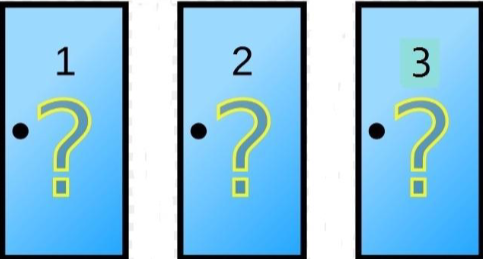

A game show where the winner got to choose between 3 doors. One door had a new car and the other two doors each hid a goat. 
After the player chose their first door, the host would reveal a door with one of the goats. 
The player could then choose if they wanted to stay with their door or switch to a different door. 

Which is the better strategy and why? 


In [ ]:
goats = make_array('first goat', 'second goat')

In [ ]:
def other_goat(x):
    if x == 'first goat':
        return 'second goat'
    elif x == 'second goat':
        return 'first goat'

In [ ]:
[other_goat('first goat'), other_goat('second goat')]

In [ ]:
hidden_behind_doors = np.append(goats, 'car')
hidden_behind_doors

In [ ]:
def monty_hall_game():
    """Return 
    [contestant's guess, what Monty reveals, what remains behind the other door]"""
    
    contestant_guess = np.random.choice(hidden_behind_doors)
    
    if contestant_guess == 'first goat':
        return [contestant_guess, 'second goat', 'car']
    
    if contestant_guess == 'second goat':
        return [contestant_guess, 'first goat', 'car']
    
    if contestant_guess == 'car':
        revealed = np.random.choice(goats)
        return [contestant_guess, revealed, other_goat(revealed)]

In [ ]:
monty_hall_game()

In [ ]:
games = Table(['Guess', 'Revealed', 'Remaining'])

for i in np.arange(10000):
    games.append(monty_hall_game())


In [ ]:
games.show(3)

In [ ]:
original_choice = games.group('Guess')
original_choice

In [ ]:
remaining_door = games.group('Remaining')
remaining_door

In [ ]:
joined = original_choice.join('Guess', remaining_door, 'Remaining')
combined = joined.relabeled(0, 'Item').relabeled(1, 'Original Door').relabeled(2, 'Remaining Door')
combined

In [ ]:
combined.barh(0)